# Mini-Challenge DEL: Hyperparameter Tuning und Model Evaluation

**Task:** Bildklassifikation mit dem Intel Image Classification Dataset (6 Klassen: buildings, forest, glacier, mountain, sea, street).

**Stage 1:** Basismodell mit CNN, LR- und Batch-Size-Tuning, Cross-Validation.

## Imports und Setup

Alle benötigten Bibliotheken: PyTorch, torchvision, HuggingFace datasets, scikit-learn, W&B.

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as transforms

# HuggingFace datasets
from datasets import load_dataset, load_from_disk

# Scikit-learn (metrics, cross-validation)
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Experiment tracking
import wandb

# Utilities
import os
from pathlib import Path

# GLobal variables
RANDOM_SEED = 42
DATA_DIR = Path("../data/intel-image-classification")

### Daten laden

Intel Image Classification Dataset von HuggingFace laden (bzw. von Disk falls bereits heruntergeladen).

In [2]:
if DATA_DIR.exists():
    print("Loading dataset from disk...")
    dataset = load_from_disk(str(DATA_DIR))
else:
    print("Downloading dataset from HuggingFace...")
    dataset = load_dataset("sfarrukhm/intel-image-classification")
    DATA_DIR.parent.mkdir(parents=True, exist_ok=True)
    dataset.save_to_disk(str(DATA_DIR))
    print(f"Dataset saved to {DATA_DIR}")

print(dataset)
print(f"\nTrain samples: {len(dataset['train'])}")
print(f"Test samples:  {len(dataset['test'])}")
print(f"\nFeatures: {dataset['train'].features}")
print(f"Labels:   {dataset['train'].features['label'].names}")

Loading dataset from disk...
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 14034
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 3000
    })
})

Train samples: 14034
Test samples:  3000

Features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'])}
Labels:   ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## Explorative Analyse

   Klasse  Train  Test  Train %  Test %
buildings   2191   437     15.6    14.6
   forest   2271   474     16.2    15.8
  glacier   2404   553     17.1    18.4
 mountain   2512   525     17.9    17.5
      sea   2274   510     16.2    17.0
   street   2382   501     17.0    16.7


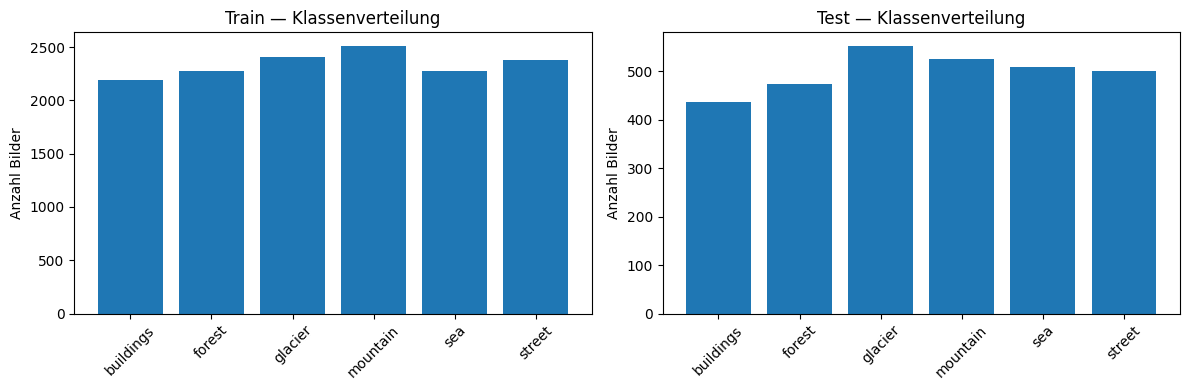

In [3]:
# Klassenverteilung im Train- und Test-Split
label_names = dataset["train"].features["label"].names
train_labels = dataset["train"]["label"]
test_labels = dataset["test"]["label"]

train_counts = pd.Series(train_labels).value_counts().sort_index()
test_counts = pd.Series(test_labels).value_counts().sort_index()

dist_df = pd.DataFrame(
    {"Klasse": label_names, "Train": train_counts.values, "Test": test_counts.values}
)
dist_df["Train %"] = (dist_df["Train"] / dist_df["Train"].sum() * 100).round(1)
dist_df["Test %"] = (dist_df["Test"] / dist_df["Test"].sum() * 100).round(1)
print(dist_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(label_names, train_counts.values)
axes[0].set_title("Train — Klassenverteilung")
axes[0].set_ylabel("Anzahl Bilder")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(label_names, test_counts.values)
axes[1].set_title("Test — Klassenverteilung")
axes[1].set_ylabel("Anzahl Bilder")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Beispielbilder

Je 2 Beispielbilder pro Klasse zur visuellen Inspektion.

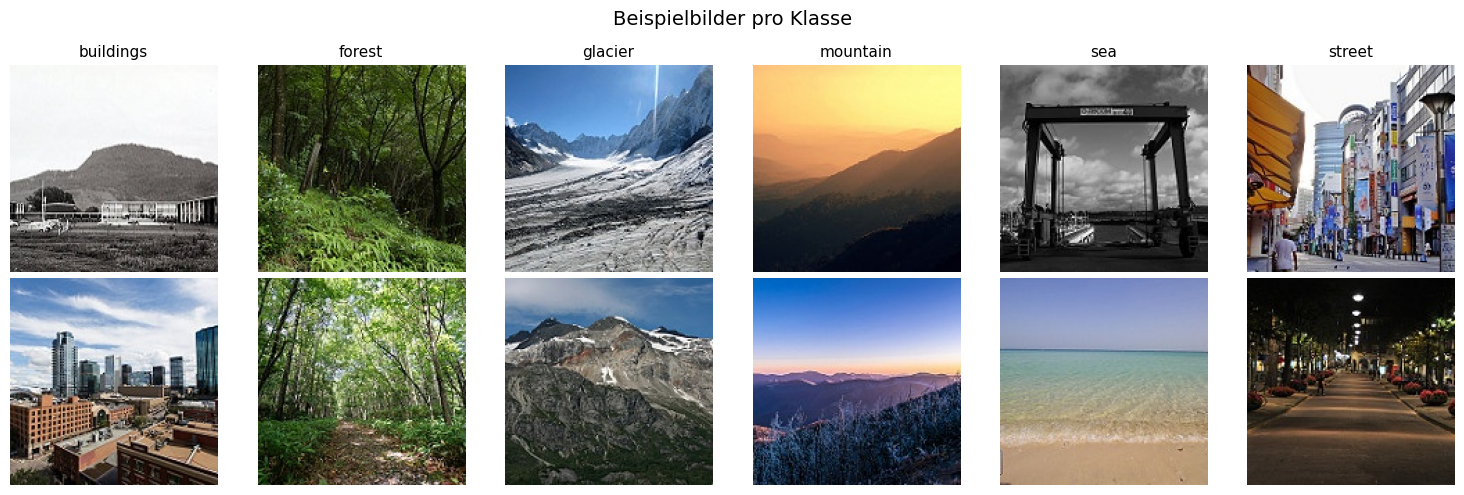

In [4]:
# Beispielbilder pro Klasse anzeigen
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
fig.suptitle("Beispielbilder pro Klasse", fontsize=14)

for class_idx, class_name in enumerate(label_names):
    class_samples = dataset["train"].filter(lambda x: x["label"] == class_idx)
    for row in range(2):
        ax = axes[row, class_idx]
        ax.imshow(class_samples[row]["image"])
        ax.axis("off")
        if row == 0:
            ax.set_title(class_name, fontsize=11)

plt.tight_layout()
plt.show()

### Bildgrössen und Pixelwerte

Prüfen, ob alle Bilder die gleiche Grösse haben und wie der Wertebereich aussieht.

In [5]:
# Bildgrössen prüfen
sample_sizes = [dataset["train"][i]["image"].size for i in range(500)]
unique_sizes = set(sample_sizes)
print(f"Einzigartige Bildgrössen (erste 500 Bilder): {unique_sizes}")

sample_img = dataset["train"][0]["image"]
img_array = np.array(sample_img)
print(f"Shape eines Bildes: {img_array.shape}")
print(f"Wertebereich: [{img_array.min()}, {img_array.max()}]")
print(f"Dtype: {img_array.dtype}")

Einzigartige Bildgrössen (erste 500 Bilder): {(150, 150)}
Shape eines Bildes: (150, 150, 3)
Wertebereich: [0, 255]
Dtype: uint8


### Pixelwert-Verteilung pro Kanal

Boxplot der mittleren Pixelwerte pro RGB-Kanal über eine Stichprobe von 200 Bildern.

/var/folders/sz/cyfjsbbn5_b4hthg95tlx0pm0000gn/T/ipykernel_4941/4087356586.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


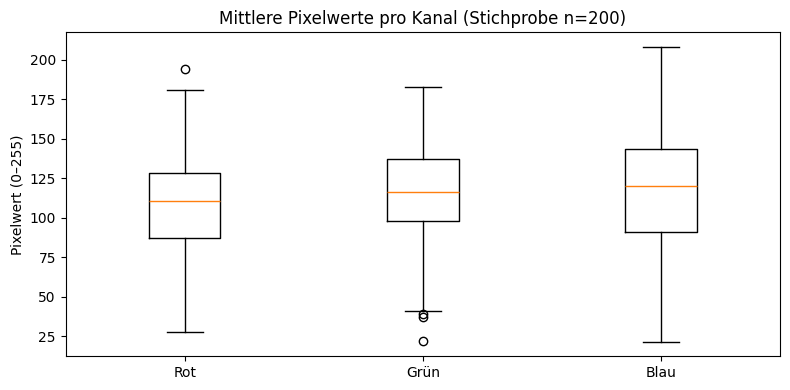

Kanal-Mittelwerte (0–255):  R=109.5,  G=115.7,  B=117.5
Kanal-Mittelwerte (0–1):    R=0.429,  G=0.454,  B=0.461


In [6]:
# Pixelwert-Verteilung pro Kanal (Stichprobe von 200 Bildern)
rng = np.random.default_rng(RANDOM_SEED)
sample_indices = rng.choice(len(dataset["train"]), size=200, replace=False)
pixel_data = {c: [] for c in ["R", "G", "B"]}

for idx in sample_indices:
    img = np.array(dataset["train"][int(idx)]["image"])
    for c, name in enumerate(["R", "G", "B"]):
        pixel_data[name].append(img[:, :, c].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(
    [pixel_data["R"], pixel_data["G"], pixel_data["B"]], labels=["Rot", "Grün", "Blau"]
)
ax.set_title("Mittlere Pixelwerte pro Kanal (Stichprobe n=200)")
ax.set_ylabel("Pixelwert (0–255)")
plt.tight_layout()
plt.show()

print(
    f"Kanal-Mittelwerte (0–255):  R={np.mean(pixel_data['R']):.1f},  G={np.mean(pixel_data['G']):.1f},  B={np.mean(pixel_data['B']):.1f}"
)
print(
    f"Kanal-Mittelwerte (0–1):    R={np.mean(pixel_data['R'])/255:.3f},  G={np.mean(pixel_data['G'])/255:.3f},  B={np.mean(pixel_data['B'])/255:.3f}"
)

## Preprocessing

### Kanal-Statistiken berechnen

Berechnung der Mittelwerte und Standardabweichungen pro RGB-Kanal über das gesamte Trainingsset. Diese werden für die Normalisierung der Bilder verwendet.

In [7]:
# Kanal-Mittelwerte und Standardabweichungen berechnen (über gesamtes Trainingsset)
channel_sum = np.zeros(3)
channel_sq_sum = np.zeros(3)
n_pixels = 0

for i in range(len(dataset["train"])):
    img = np.array(dataset["train"][i]["image"], dtype=np.float32) / 255.0
    channel_sum += img.sum(axis=(0, 1))
    channel_sq_sum += (img**2).sum(axis=(0, 1))
    n_pixels += img.shape[0] * img.shape[1]

channel_mean = channel_sum / n_pixels
channel_std = np.sqrt(channel_sq_sum / n_pixels - channel_mean**2)

print(f"Channel means: {channel_mean}")
print(f"Channel stds:  {channel_std}")

Channel means: [0.43018116 0.45747542 0.45382798]
Channel stds:  [0.26941103 0.26793626 0.29834034]


### Transform-Pipeline

RandomCrop (64x64) für Training: Aus den ~150x150 Bildern wird pro Aufruf ein zufälliger 64x64-Ausschnitt genommen — das wirkt als Data Augmentation.
CenterCrop (64x64) für Validation/Test: Deterministisch den mittleren Ausschnitt für konsistente Evaluation.

In [8]:
# Train: RandomResizedCrop + HorizontalFlip als Data Augmentation
transform_train = transforms.Compose(
    [
        transforms.RandomResizedCrop(64, scale=(0.4, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),  # PIL -> Tensor [0,1], HWC -> CHW
        transforms.Normalize(mean=channel_mean.tolist(), std=channel_std.tolist()),
    ]
)

# Validation/Test: CenterCrop für deterministische Evaluation
transform_eval = transforms.Compose(
    [
        transforms.CenterCrop(64),  # Mittlerer 64x64 Ausschnitt
        transforms.ToTensor(),
        transforms.Normalize(mean=channel_mean.tolist(), std=channel_std.tolist()),
    ]
)

### PyTorch Dataset-Wrapper

Wrapper-Klasse, die das HuggingFace Dataset in ein PyTorch Dataset konvertiert und den Transform anwendet.

In [9]:
# PyTorch Dataset-Wrapper für HuggingFace Dataset
class IntelImageDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        sample = self.hf_dataset[idx]
        image = sample["image"]
        label = sample["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

### Train/Validation/Test-Split

80/20-Split des Trainingssets in Train und Validation (stratifiziert nach Klasse). Das Testset bleibt unverändert.

In [10]:
# Train/Validation-Split (80/20, stratifiziert nach Klasse)
train_indices, val_indices = train_test_split(
    range(len(dataset["train"])),
    test_size=0.2,
    random_state=42,
    stratify=dataset["train"]["label"],
)

hf_train = dataset["train"].select(train_indices)
hf_val = dataset["train"].select(val_indices)

train_dataset = IntelImageDataset(hf_train, transform=transform_train)
val_dataset = IntelImageDataset(hf_val, transform=transform_eval)
test_dataset = IntelImageDataset(dataset["test"], transform=transform_eval)

print(f"Train:      {len(train_dataset)} Bilder")
print(f"Validation: {len(val_dataset)} Bilder")
print(f"Test:       {len(test_dataset)} Bilder")

Train:      11227 Bilder
Validation: 2807 Bilder
Test:       3000 Bilder


### DataLoaders erstellen

DataLoader für Train, Validation und Test mit initialer Batch-Size von 64. Sanity Check der Batch-Dimensionen und Pixelwerte.

In [11]:
# DataLoaders erstellen
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Sanity Check: ein Batch laden
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")  # [64, 3, 150, 150]
print(f"Labels shape: {labels.shape}")  # [64]
print(f"Pixel range:  [{images.min():.2f}, {images.max():.2f}]")

Batch shape: torch.Size([64, 3, 64, 64])
Labels shape: torch.Size([64])
Pixel range:  [-1.71, 2.12]


## Schritt 1: Setup (Device, Metriken, W&B)

In [12]:
# Device Setup (Apple Silicon MPS / CUDA / CPU)
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Device: {device}")

# Kostenfunktion
criterion = nn.CrossEntropyLoss()

# Klassennamen
NUM_CLASSES = 6
CLASS_NAMES = dataset["train"].features["label"].names
print(f"Klassen ({NUM_CLASSES}): {CLASS_NAMES}")

Device: mps
Klassen (6): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


### W&B Login

Authentifizierung bei Weights & Biases für Experiment-Tracking.

In [13]:
# W&B Login
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/lucamanna/.netrc.
wandb: Currently logged in as: mannaluca02 (mannaluca02-fachhochschule-nordwestschweiz-fhnw) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Schritt 2: Training- und Evaluierungsfunktionen

In [14]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Trainiert eine Epoche. Gibt (loss, accuracy) zurück."""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for X, Y in loader:
        X, Y = X.to(device), Y.to(device)
        pred = model(X)
        loss = criterion(pred, Y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (pred.argmax(dim=1) == Y).sum().item()
        total += Y.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    """Evaluiert das Modell. Gibt (loss, accuracy) zurück."""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # Keine Gradientenberechnung für Evaluation
        for X, Y in loader:
            X, Y = X.to(device), Y.to(device)
            pred = model(X)
            total_loss += criterion(pred, Y).item()
            correct += (pred.argmax(dim=1) == Y).sum().item()
            total += Y.size(0)

    return total_loss / len(loader), correct / total


def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs,
    log_wandb=True,
):
    """Kompletter Trainingsloop mit optionalem W&B-Logging. Gibt History-Dict zurück."""
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if log_wandb:
            wandb.log(
                {
                    "epoch": epoch,
                    "train_loss": train_loss,
                    "train_acc": train_acc,
                    "val_loss": val_loss,
                    "val_acc": val_acc,
                }
            )

        print(
            f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}"
        )

    return history


def plot_training(history, title="Lernkurven"):
    """Plottet Loss und Accuracy (Train vs Val)."""
    epochs = range(len(history["train_loss"]))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, history["train_loss"], "b-", label="Train")
    ax1.plot(epochs, history["val_loss"], "r-", label="Validation")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"{title} — Cross-Entropy Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history["train_acc"], "b-", label="Train")
    ax2.plot(epochs, history["val_acc"], "r-", label="Validation")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title(f"{title} — Accuracy")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Schritt 3: CNN-Basismodell

Architektur für 64x64x3 Bilder (Resize zur Verkürzung der Trainingszeit):
- 3 Conv-Blöcke (Conv2d + ReLU + MaxPool2d) für Feature-Extraktion
- 2 Fully Connected Layers für Klassifikation
- Kein Dropout, kein BatchNorm (Vorgabe Stage 1)
- Output: raw logits (CrossEntropyLoss enthält Softmax)
- Die Linear-Layer-Grösse wird automatisch aus der Bildgrösse berechnet

In [15]:
IMG_SIZE = 64  # Muss mit transforms.Resize übereinstimmen


class BaseCNN(nn.Module):
    def __init__(self, num_classes=6, img_size=IMG_SIZE):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: img_size -> img_size/2
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2: img_size/2 -> img_size/4
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3: img_size/4 -> img_size/8
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        # Feature-Map-Grösse nach 3x MaxPool2d(2)
        feat_size = img_size // 8
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * feat_size * feat_size, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Modell instanzieren und Architektur prüfen
model = BaseCNN(NUM_CLASSES).to(device)
print(model)
print(f"\nParameter: {sum(p.numel() for p in model.parameters()):,}")

# Forward-Pass Test mit aktueller Bildgrösse
with torch.no_grad():
    test_input = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
    test_output = model(test_input)
    print(f"\nInput:  {test_input.shape}")
    print(f"Output: {test_output.shape}")  # Erwartet: [2, 6]

BaseCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=6, bias=True)
  )
)

Parameter: 548,774

Input:  torch.Size([2, 3, 64, 64])
Output: torch.Size([2, 6])


## Schritt 4: Overfitting-Test

Laut Aufgabenstellung (Punkt 3d): Trainiere auf einem einzelnen Batch. Der Loss muss gegen 0 gehen — das bestätigt, dass Modell und Training-Loop korrekt funktionieren.

Iter   0 | Loss: 1.8019 | Acc: 0.0781
Iter  40 | Loss: 1.0764 | Acc: 0.6562
Iter  80 | Loss: 0.4788 | Acc: 0.8438
Iter 120 | Loss: 0.8486 | Acc: 0.8594
Iter 160 | Loss: 0.0235 | Acc: 1.0000
Iter 199 | Loss: 0.0059 | Acc: 1.0000


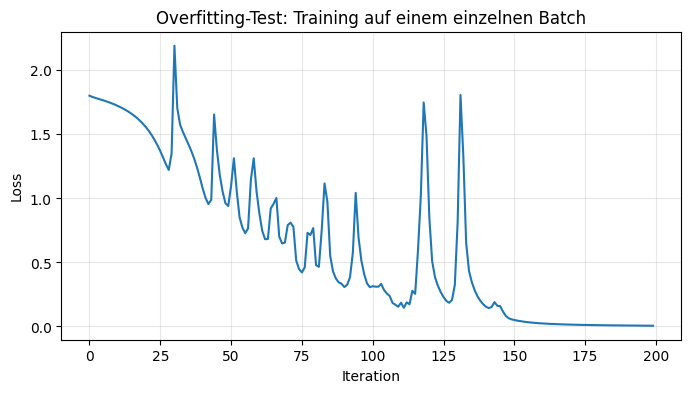


Final Loss: 0.005901
BESTANDEN — Modell kann einen Batch overfitten.


In [16]:
# Overfitting-Test: ein einzelner Batch, 200 Iterationen mit höherer LR
overfit_model = BaseCNN(NUM_CLASSES).to(device)
overfit_optimizer = optim.SGD(overfit_model.parameters(), lr=0.05)
overfit_criterion = nn.CrossEntropyLoss()

# Einen Batch extrahieren
single_batch_X, single_batch_Y = next(iter(train_loader))
single_batch_X = single_batch_X.to(device)
single_batch_Y = single_batch_Y.to(device)

overfit_losses = []
overfit_model.train()

for i in range(200):
    pred = overfit_model(single_batch_X)
    loss = overfit_criterion(pred, single_batch_Y)

    overfit_optimizer.zero_grad()
    loss.backward()
    overfit_optimizer.step()

    overfit_losses.append(loss.item())
    if i % 40 == 0 or i == 199:
        acc = (pred.argmax(dim=1) == single_batch_Y).float().mean().item()
        print(f"Iter {i:3d} | Loss: {loss.item():.4f} | Acc: {acc:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(overfit_losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Overfitting-Test: Training auf einem einzelnen Batch")
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nFinal Loss: {overfit_losses[-1]:.6f}")
if overfit_losses[-1] < 0.1:
    print("BESTANDEN — Modell kann einen Batch overfitten.")
else:
    print("NICHT BESTANDEN — Loss konvergiert nicht gegen 0.")

## Schritt 5: Basis-Training mit W&B

Training des Basismodells mit SGD (ohne Momentum), lr=0.01, 25 Epochs. W&B trackt alle Metriken.

In [17]:
# Basis-Training
run = wandb.init(
    project="del-mini-challenge",
    name="base-model-sgd-lr0.01",
    config={
        "architecture": "BaseCNN",
        "optimizer": "SGD",
        "lr": 0.01,
        "momentum": 0.0,
        "batch_size": BATCH_SIZE,
        "epochs": 25,
        "num_classes": NUM_CLASSES,
    },
)

model = BaseCNN(NUM_CLASSES).to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01)
wandb.watch(model, log="all")

history_base = train_model(
    model, train_loader, val_loader, criterion, optimizer, device, epochs=25
)

wandb.finish()

Epoch   0 | Train Loss: 1.7504  Acc: 0.2592 | Val Loss: 1.6206  Acc: 0.3951
Epoch   1 | Train Loss: 1.4001  Acc: 0.4629 | Val Loss: 1.4040  Acc: 0.4475
Epoch   2 | Train Loss: 1.1892  Acc: 0.5358 | Val Loss: 1.3626  Acc: 0.4703
Epoch   3 | Train Loss: 1.1027  Acc: 0.5677 | Val Loss: 1.4648  Acc: 0.4760
Epoch   4 | Train Loss: 1.0645  Acc: 0.5816 | Val Loss: 1.4493  Acc: 0.4891
Epoch   5 | Train Loss: 1.0306  Acc: 0.5950 | Val Loss: 1.2799  Acc: 0.5094
Epoch   6 | Train Loss: 1.0022  Acc: 0.6127 | Val Loss: 1.3167  Acc: 0.5077
Epoch   7 | Train Loss: 0.9689  Acc: 0.6265 | Val Loss: 1.3812  Acc: 0.5230
Epoch   8 | Train Loss: 0.9392  Acc: 0.6412 | Val Loss: 1.2362  Acc: 0.5440
Epoch   9 | Train Loss: 0.9040  Acc: 0.6608 | Val Loss: 1.1555  Acc: 0.5547
Epoch  10 | Train Loss: 0.8874  Acc: 0.6607 | Val Loss: 1.4064  Acc: 0.5073
Epoch  11 | Train Loss: 0.8610  Acc: 0.6757 | Val Loss: 1.0621  Acc: 0.6021
Epoch  12 | Train Loss: 0.8497  Acc: 0.6811 | Val Loss: 1.1378  Acc: 0.5882
Epoch  13 | 

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch  24 | Train Loss: 0.6694  Acc: 0.7569 | Val Loss: 1.1852  Acc: 0.5953


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_acc,▁▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇██████
train_loss,█▆▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val_acc,▁▂▃▃▃▄▄▄▅▅▄▆▆▆▆▆▆▅▆▆▇▇██▆
val_loss,█▆▅▆▆▄▅▅▄▃▆▂▃▃▄▃▂▅▃▄▂▁▁▁▃
epoch,24
train_acc,0.75693
train_loss,0.66945
val_acc,0.5953
val_loss,1.18519


### Lernkurven Basismodell

Visualisierung von Loss und Accuracy (Train vs. Validation) über die 25 Epochs.

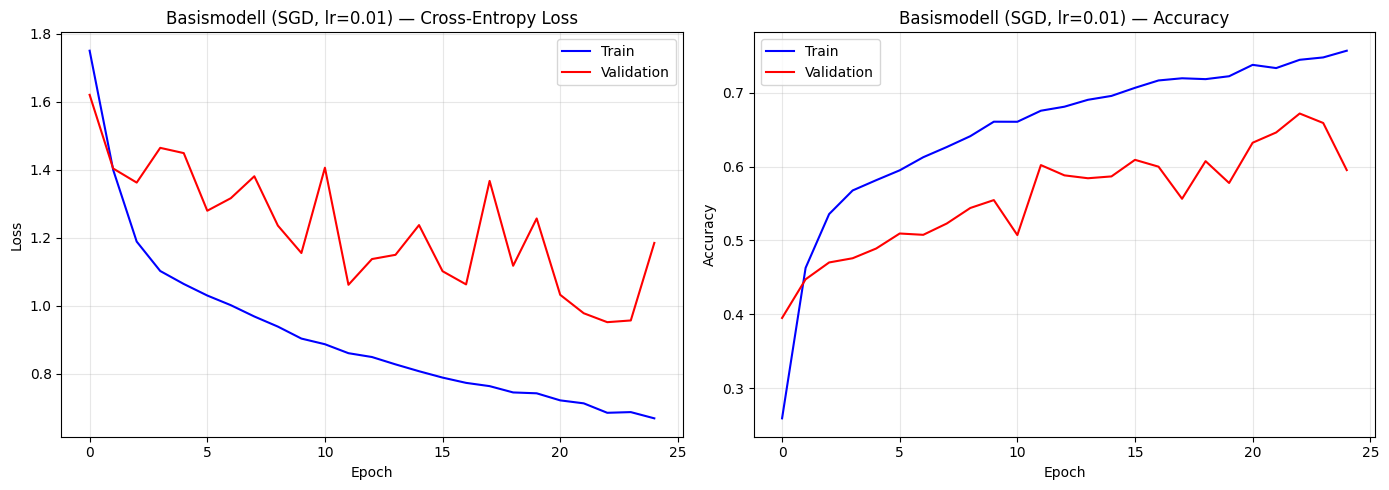

In [18]:
plot_training(history_base, title="Basismodell (SGD, lr=0.01)")

## Schritt 6: Lernraten-Tuning

Wir testen mehrere Lernraten (0.001, 0.005, 0.01, 0.05, 0.1) mit SGD ohne Momentum. Jedes Training wird als eigener W&B-Run geloggt. Anschliessend vergleichen wir die Lernkurven.

In [19]:
# LR-Tuning: mehrere Lernraten vergleichen
learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1]
lr_histories = {}
LR_EPOCHS = 20

for lr in learning_rates:
    print(f"\n{'='*60}")
    print(f"Training mit lr={lr}")
    print(f"{'='*60}")

    run = wandb.init(
        project="del-mini-challenge",
        name=f"lr-tuning-{lr}",
        config={
            "architecture": "BaseCNN",
            "optimizer": "SGD",
            "lr": lr,
            "momentum": 0.0,
            "batch_size": BATCH_SIZE,
            "epochs": LR_EPOCHS,
            "experiment": "lr-tuning",
        },
        reinit=True,
    )

    model_lr = BaseCNN(NUM_CLASSES).to(device)
    optimizer_lr = optim.SGD(model_lr.parameters(), lr=lr)

    lr_histories[lr] = train_model(
        model_lr,
        train_loader,
        val_loader,
        criterion,
        optimizer_lr,
        device,
        epochs=LR_EPOCHS,
    )

    wandb.finish()


Training mit lr=0.001


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch   0 | Train Loss: 1.7894  Acc: 0.2326 | Val Loss: 1.7871  Acc: 0.2658
Epoch   1 | Train Loss: 1.7844  Acc: 0.2810 | Val Loss: 1.7814  Acc: 0.2928
Epoch   2 | Train Loss: 1.7787  Acc: 0.3189 | Val Loss: 1.7750  Acc: 0.3616
Epoch   3 | Train Loss: 1.7718  Acc: 0.3699 | Val Loss: 1.7666  Acc: 0.4211
Epoch   4 | Train Loss: 1.7624  Acc: 0.4156 | Val Loss: 1.7549  Acc: 0.4311
Epoch   5 | Train Loss: 1.7487  Acc: 0.4320 | Val Loss: 1.7374  Acc: 0.4286
Epoch   6 | Train Loss: 1.7266  Acc: 0.4436 | Val Loss: 1.7095  Acc: 0.4232
Epoch   7 | Train Loss: 1.6913  Acc: 0.4405 | Val Loss: 1.6652  Acc: 0.4072
Epoch   8 | Train Loss: 1.6347  Acc: 0.4333 | Val Loss: 1.6018  Acc: 0.3972
Epoch   9 | Train Loss: 1.5577  Acc: 0.4310 | Val Loss: 1.5360  Acc: 0.3986
Epoch  10 | Train Loss: 1.4861  Acc: 0.4372 | Val Loss: 1.4918  Acc: 0.4115
Epoch  11 | Train Loss: 1.4310  Acc: 0.4528 | Val Loss: 1.4619  Acc: 0.4222
Epoch  12 | Train Loss: 1.3923  Acc: 0.4647 | Val Loss: 1.4472  Acc: 0.4268
Epoch  13 | 

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch  19 | Train Loss: 1.2459  Acc: 0.5165 | Val Loss: 1.3532  Acc: 0.4621


...


Training mit lr=0.1


Epoch   0 | Train Loss: 1.3843  Acc: 0.4431 | Val Loss: 1.8312  Acc: 0.3591
Epoch   1 | Train Loss: 1.1127  Acc: 0.5563 | Val Loss: 1.2350  Acc: 0.5123
Epoch   2 | Train Loss: 0.9821  Acc: 0.6152 | Val Loss: 1.2493  Acc: 0.5354
Epoch   3 | Train Loss: 0.9120  Acc: 0.6422 | Val Loss: 1.1326  Acc: 0.5857
Epoch   4 | Train Loss: 0.8423  Acc: 0.6817 | Val Loss: 1.1292  Acc: 0.5907
Epoch   5 | Train Loss: 0.7762  Acc: 0.7120 | Val Loss: 1.0266  Acc: 0.6095
Epoch   6 | Train Loss: 0.7285  Acc: 0.7234 | Val Loss: 1.1389  Acc: 0.5850
Epoch   7 | Train Loss: 0.6898  Acc: 0.7420 | Val Loss: 0.9185  Acc: 0.6626
Epoch   8 | Train Loss: 0.6544  Acc: 0.7600 | Val Loss: 1.0440  Acc: 0.6427
Epoch   9 | Train Loss: 0.6323  Acc: 0.7647 | Val Loss: 0.9496  Acc: 0.6459
Epoch  10 | Train Loss: 0.6231  Acc: 0.7699 | Val Loss: 1.1208  Acc: 0.6074
Epoch  11 | Train Loss: 0.5833  Acc: 0.7861 | Val Loss: 1.0073  Acc: 0.6544
Epoch  12 | Train Loss: 0.5681  Acc: 0.7915 | Val Loss: 1.0571  Acc: 0.6409
Epoch  13 | 

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch  19 | Train Loss: 0.4757  Acc: 0.8247 | Val Loss: 0.9294  Acc: 0.7000


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▃▄▅▅▆▆▆▇▇▇▇▇███████
train_loss,█▆▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁
val_acc,▁▄▅▆▆▆▆▇▇▇▆▇▇▇███▇██
val_loss,█▄▄▃▃▂▃▁▂▁▃▂▂▃▁▁▂▂▁▁
epoch,19
train_acc,0.82471
train_loss,0.47574
val_acc,0.70004
val_loss,0.92935


### Vergleichsplot und beste Lernrate

Validation Loss und Accuracy aller getesteten Lernraten im Vergleich. Auswahl der besten LR basierend auf maximaler Validation Accuracy.

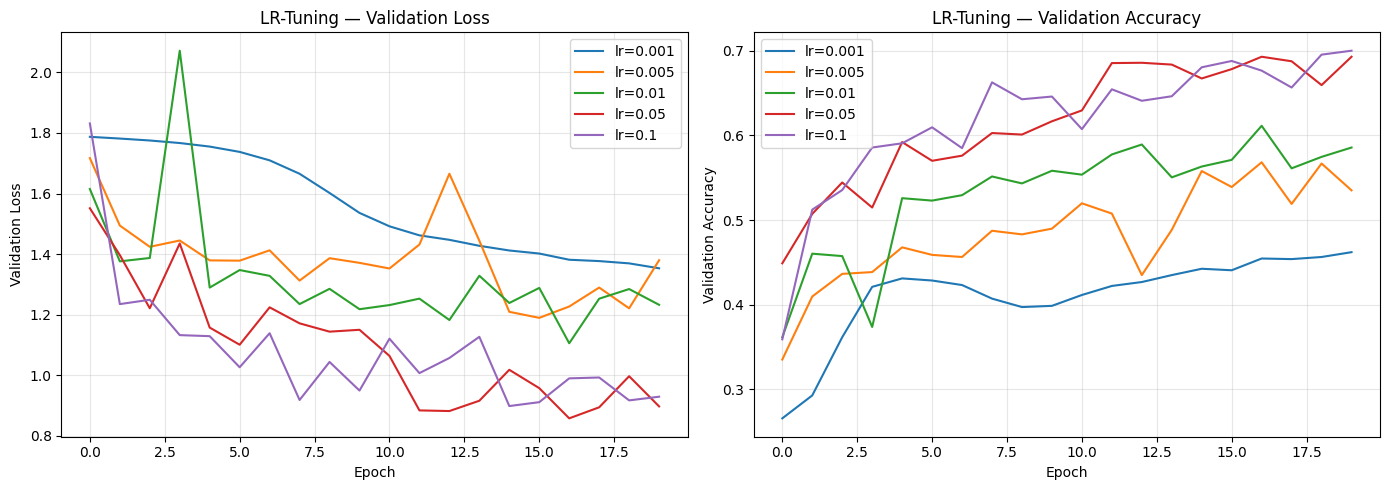


Beste Lernrate: 0.1 (max Val Accuracy: 0.7000)


In [20]:
# Vergleichsplot: alle Lernraten
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for lr, hist in lr_histories.items():
    epochs = range(len(hist["val_loss"]))
    ax1.plot(epochs, hist["val_loss"], label=f"lr={lr}")
    ax2.plot(epochs, hist["val_acc"], label=f"lr={lr}")

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Validation Loss")
ax1.set_title("LR-Tuning — Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel("Epoch")
ax2.set_ylabel("Validation Accuracy")
ax2.set_title("LR-Tuning — Validation Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Beste LR ermitteln
best_lr = max(lr_histories.keys(), key=lambda lr: max(lr_histories[lr]["val_acc"]))
best_val_acc = max(lr_histories[best_lr]["val_acc"])
print(f"\nBeste Lernrate: {best_lr} (max Val Accuracy: {best_val_acc:.4f})")

### Diskussion LR-Tuning

**Beobachtungen:**
- Sehr kleine Lernraten (0.001) konvergieren langsam — das Modell hat nach 20 Epochs noch nicht sein Potenzial ausgeschöpft.
- Zu grosse Lernraten (0.1) können instabil werden: der Loss oszilliert oder das Training divergiert.
- Mittlere Lernraten (0.005–0.05) liefern in der Regel die beste Balance zwischen Konvergenzgeschwindigkeit und Stabilität.

**Theoretischer Hintergrund:** Bei SGD ohne Momentum bestimmt die Lernrate die Schrittgrösse im Gradientenabstieg. Eine zu kleine LR führt zu langsamer Konvergenz, eine zu grosse LR kann über das Minimum "hinausschiessen" und zu Divergenz führen (vgl. Vorlesungsfolien DEL, Optimizers).

## Schritt 7: Batch-Size-Tuning

Wir testen verschiedene Batch-Sizes (16, 32, 64, 128) mit der besten Lernrate aus Schritt 6.

In [21]:
# Batch-Size-Tuning mit bester LR
batch_sizes = [16, 32, 64, 128]
bs_histories = {}
BS_EPOCHS = 20

for bs in batch_sizes:
    print(f"\n{'='*60}")
    print(f"Training mit batch_size={bs}, lr={best_lr}")
    print(f"{'='*60}")

    # Neue DataLoader mit angepasster Batch-Size
    bs_train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    bs_val_loader = DataLoader(val_dataset, batch_size=bs, shuffle=False)

    run = wandb.init(
        project="del-mini-challenge",
        name=f"bs-tuning-{bs}",
        config={
            "architecture": "BaseCNN",
            "optimizer": "SGD",
            "lr": best_lr,
            "momentum": 0.0,
            "batch_size": bs,
            "epochs": BS_EPOCHS,
            "experiment": "batch-size-tuning",
        },
        reinit=True,
    )

    model_bs = BaseCNN(NUM_CLASSES).to(device)
    optimizer_bs = optim.SGD(model_bs.parameters(), lr=best_lr)

    bs_histories[bs] = train_model(
        model_bs,
        bs_train_loader,
        bs_val_loader,
        criterion,
        optimizer_bs,
        device,
        epochs=BS_EPOCHS,
    )

    wandb.finish()


Training mit batch_size=16, lr=0.1


Epoch   0 | Train Loss: 1.2422  Acc: 0.5089 | Val Loss: 1.1128  Acc: 0.5579
Epoch   1 | Train Loss: 0.9407  Acc: 0.6396 | Val Loss: 1.4636  Acc: 0.5212
Epoch   2 | Train Loss: 0.8413  Acc: 0.6871 | Val Loss: 1.1616  Acc: 0.5853
Epoch   3 | Train Loss: 0.7573  Acc: 0.7215 | Val Loss: 0.9731  Acc: 0.6562
Epoch   4 | Train Loss: 0.7157  Acc: 0.7343 | Val Loss: 1.3958  Acc: 0.5714
Epoch   5 | Train Loss: 0.6819  Acc: 0.7480 | Val Loss: 0.9465  Acc: 0.6808
Epoch   6 | Train Loss: 0.6615  Acc: 0.7638 | Val Loss: 1.0368  Acc: 0.6366
Epoch   7 | Train Loss: 0.6403  Acc: 0.7640 | Val Loss: 1.6360  Acc: 0.5689
Epoch   8 | Train Loss: 0.6144  Acc: 0.7791 | Val Loss: 0.9558  Acc: 0.6755
Epoch   9 | Train Loss: 0.5986  Acc: 0.7844 | Val Loss: 0.9097  Acc: 0.6744
Epoch  10 | Train Loss: 0.5995  Acc: 0.7857 | Val Loss: 0.9308  Acc: 0.6815
Epoch  11 | Train Loss: 0.5734  Acc: 0.7940 | Val Loss: 1.1448  Acc: 0.6608
Epoch  12 | Train Loss: 0.5679  Acc: 0.7920 | Val Loss: 0.9463  Acc: 0.6744
Epoch  13 | 

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch  19 | Train Loss: 0.5236  Acc: 0.8089 | Val Loss: 0.9295  Acc: 0.6936


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▄▅▆▆▇▇▇▇▇▇█████████
train_loss,█▅▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_acc,▂▁▄▆▃▇▆▃▇▇█▇▇██▇█▆▆█
val_loss,▃▆▃▂▆▁▂█▁▁▁▃▁▂▂▂▂▂▃▁
epoch,19
train_acc,0.80894
train_loss,0.52362
val_acc,0.69362
val_loss,0.92952


...


Training mit batch_size=128, lr=0.1


Epoch   0 | Train Loss: 1.4810  Acc: 0.4000 | Val Loss: 1.8405  Acc: 0.3160
Epoch   1 | Train Loss: 1.2168  Acc: 0.5133 | Val Loss: 1.2315  Acc: 0.5045
Epoch   2 | Train Loss: 1.0690  Acc: 0.5755 | Val Loss: 1.5677  Acc: 0.4560
Epoch   3 | Train Loss: 1.0237  Acc: 0.5977 | Val Loss: 1.4212  Acc: 0.4745
Epoch   4 | Train Loss: 0.9472  Acc: 0.6321 | Val Loss: 1.3827  Acc: 0.4923
Epoch   5 | Train Loss: 0.8990  Acc: 0.6562 | Val Loss: 1.1277  Acc: 0.5768
Epoch   6 | Train Loss: 0.8568  Acc: 0.6722 | Val Loss: 1.0186  Acc: 0.5989
Epoch   7 | Train Loss: 0.8173  Acc: 0.6888 | Val Loss: 1.2468  Acc: 0.5394
Epoch   8 | Train Loss: 0.7976  Acc: 0.7023 | Val Loss: 1.0164  Acc: 0.6252
Epoch   9 | Train Loss: 0.7838  Acc: 0.7137 | Val Loss: 1.2399  Acc: 0.5625
Epoch  10 | Train Loss: 0.7446  Acc: 0.7220 | Val Loss: 1.0619  Acc: 0.6145
Epoch  11 | Train Loss: 0.7104  Acc: 0.7376 | Val Loss: 0.9041  Acc: 0.6765
Epoch  12 | Train Loss: 0.6799  Acc: 0.7470 | Val Loss: 0.8918  Acc: 0.6665
Epoch  13 | 

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch  19 | Train Loss: 0.5856  Acc: 0.7863 | Val Loss: 1.0532  Acc: 0.6380


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▃▄▅▅▆▆▆▆▇▇▇▇█▇█████
train_loss,█▆▅▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁
val_acc,▁▅▄▄▄▆▆▅▇▆▇██▇█▇█▇█▇
val_loss,█▄▆▅▅▃▂▄▂▄▂▁▁▂▁▂▁▃▁▂
epoch,19
train_acc,0.78632
train_loss,0.58562
val_acc,0.63805
val_loss,1.05318


### Vergleichsplot und beste Batch-Size

Validation Loss und Accuracy aller getesteten Batch-Sizes im Vergleich. Auswahl der besten Batch-Size basierend auf maximaler Validation Accuracy.

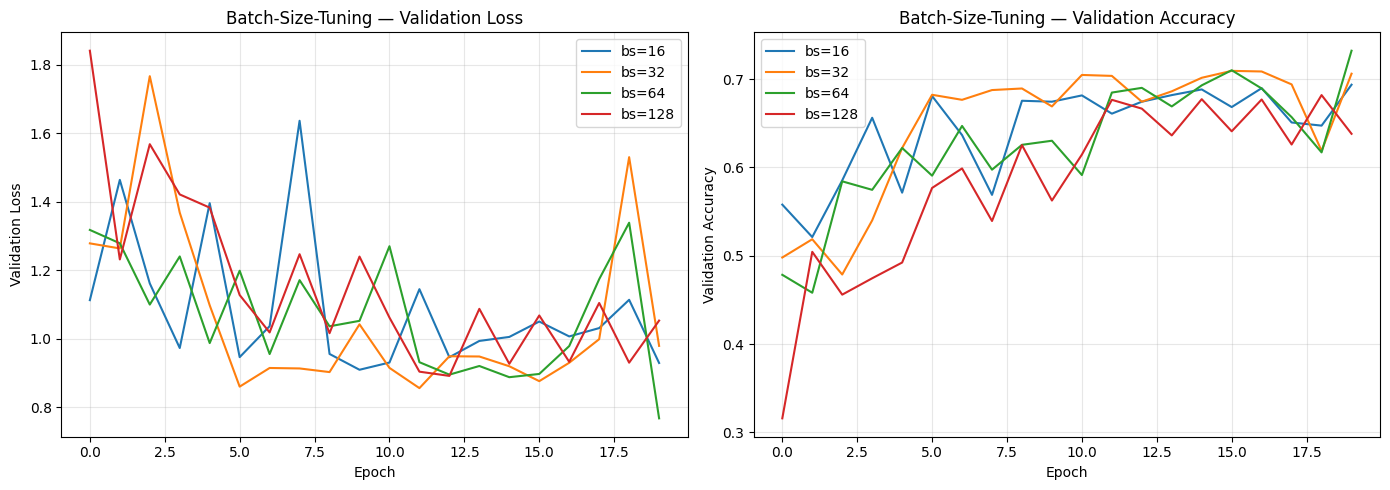


Beste Batch-Size: 64 (max Val Accuracy: 0.7321)

Beste Hyperparameter für Stage 1: lr=0.1, batch_size=64


In [22]:
# Vergleichsplot: alle Batch-Sizes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for bs, hist in bs_histories.items():
    epochs = range(len(hist["val_loss"]))
    ax1.plot(epochs, hist["val_loss"], label=f"bs={bs}")
    ax2.plot(epochs, hist["val_acc"], label=f"bs={bs}")

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Validation Loss")
ax1.set_title("Batch-Size-Tuning — Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel("Epoch")
ax2.set_ylabel("Validation Accuracy")
ax2.set_title("Batch-Size-Tuning — Validation Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Beste Batch-Size ermitteln
best_bs = max(bs_histories.keys(), key=lambda bs: max(bs_histories[bs]["val_acc"]))
best_bs_acc = max(bs_histories[best_bs]["val_acc"])
print(f"\nBeste Batch-Size: {best_bs} (max Val Accuracy: {best_bs_acc:.4f})")
print(f"\nBeste Hyperparameter für Stage 1: lr={best_lr}, batch_size={best_bs}")

### Diskussion Batch-Size-Tuning

**Beobachtungen:**
- Kleinere Batch-Sizes (16, 32) führen zu mehr Gewichtsupdates pro Epoche und können durch die stochastischere Gradientenschätzung schneller konvergieren, sind aber auch lauter.
- Grössere Batch-Sizes (64, 128) haben stabilere Gradienten, brauchen aber tendenziell mehr Epochs oder eine angepasste LR.
- Die Wahl der Batch-Size beeinflusst sowohl die Trainingsgeschwindigkeit (wall-clock time) als auch die Generalisierung.

**Theoretischer Hintergrund:** Kleinere Batches erzeugen mehr Rauschen im Gradienten, was als implizite Regularisierung wirken und zu besserer Generalisierung führen kann. Grössere Batches liefern genauere Gradientenschätzungen, neigen aber dazu, in scharfe Minima zu konvergieren (vgl. "On Large-Batch Training for Deep Learning", Keskar et al., 2017).

## Schritt 8: Cross-Validation (Statistischer Fehler)

3-Fold Cross-Validation auf dem gesamten Trainingsset mit den besten Hyperparametern. Ziel: Schätzung der Generalisierungsperformance mit Mittelwert und Standardabweichung.

In [23]:
# Cross-Validation: 3-Fold auf gesamtem Trainingsset
K_FOLDS = 3
CV_EPOCHS = 20

# Gesamtes Trainingsset (ohne Split) für CV
full_train_dataset = IntelImageDataset(dataset["train"], transform=transform_train)
full_eval_dataset = IntelImageDataset(dataset["train"], transform=transform_eval)

kfold = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
fold_results = []

for fold, (train_ids, val_ids) in enumerate(kfold.split(full_train_dataset)):
    print(f"\n{'='*60}")
    print(f"FOLD {fold + 1}/{K_FOLDS}")
    print(f"{'='*60}")

    # DataLoader pro Fold via SubsetRandomSampler
    fold_train_loader = DataLoader(
        full_train_dataset,
        batch_size=best_bs,
        sampler=torch.utils.data.SubsetRandomSampler(train_ids),
    )
    fold_val_loader = DataLoader(
        full_eval_dataset,
        batch_size=best_bs,
        sampler=torch.utils.data.SubsetRandomSampler(val_ids),
    )

    run = wandb.init(
        project="del-mini-challenge",
        name=f"cv-fold-{fold+1}",
        config={
            "architecture": "BaseCNN",
            "optimizer": "SGD",
            "lr": best_lr,
            "batch_size": best_bs,
            "epochs": CV_EPOCHS,
            "experiment": "cross-validation",
            "fold": fold + 1,
            "k_folds": K_FOLDS,
        },
        reinit=True,
    )

    model_cv = BaseCNN(NUM_CLASSES).to(device)
    optimizer_cv = optim.SGD(model_cv.parameters(), lr=best_lr)

    history_cv = train_model(
        model_cv,
        fold_train_loader,
        fold_val_loader,
        criterion,
        optimizer_cv,
        device,
        epochs=CV_EPOCHS,
    )

    best_fold_acc = max(history_cv["val_acc"])
    final_fold_acc = history_cv["val_acc"][-1]
    fold_results.append(
        {
            "fold": fold + 1,
            "best_val_acc": best_fold_acc,
            "final_val_acc": final_fold_acc,
            "history": history_cv,
        }
    )

    print(
        f"\nFold {fold+1}: Best Val Acc = {best_fold_acc:.4f}, Final Val Acc = {final_fold_acc:.4f}"
    )
    wandb.finish()


FOLD 1/3


Epoch   0 | Train Loss: 1.4095  Acc: 0.4357 | Val Loss: 1.8297  Acc: 0.3339
Epoch   1 | Train Loss: 1.1263  Acc: 0.5471 | Val Loss: 1.2372  Acc: 0.4957
Epoch   2 | Train Loss: 1.0029  Acc: 0.6057 | Val Loss: 1.4820  Acc: 0.4746
Epoch   3 | Train Loss: 0.9209  Acc: 0.6484 | Val Loss: 1.1942  Acc: 0.5592
Epoch   4 | Train Loss: 0.8528  Acc: 0.6797 | Val Loss: 1.0669  Acc: 0.6116
Epoch   5 | Train Loss: 0.8099  Acc: 0.6983 | Val Loss: 1.4390  Acc: 0.5395
Epoch   6 | Train Loss: 0.7588  Acc: 0.7203 | Val Loss: 1.4131  Acc: 0.5254
Epoch   7 | Train Loss: 0.7128  Acc: 0.7364 | Val Loss: 1.4042  Acc: 0.5622
Epoch   8 | Train Loss: 0.6849  Acc: 0.7502 | Val Loss: 1.1524  Acc: 0.5956
Epoch   9 | Train Loss: 0.6517  Acc: 0.7587 | Val Loss: 1.1782  Acc: 0.6045
Epoch  10 | Train Loss: 0.6347  Acc: 0.7649 | Val Loss: 1.5080  Acc: 0.5368
Epoch  11 | Train Loss: 0.6023  Acc: 0.7824 | Val Loss: 1.0160  Acc: 0.6291
Epoch  12 | Train Loss: 0.5855  Acc: 0.7889 | Val Loss: 0.9543  Acc: 0.6678
Epoch  13 | 

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch  19 | Train Loss: 0.4922  Acc: 0.8221 | Val Loss: 1.5318  Acc: 0.5774

Fold 1: Best Val Acc = 0.6883, Final Val Acc = 0.5774


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▃▄▅▅▆▆▆▇▇▇▇▇▇███▇██
train_loss,█▆▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁▂▁▁
val_acc,▁▄▄▅▆▅▅▆▆▆▅▇█▇▅█▃▇█▆
val_loss,▇▃▅▃▂▅▅▅▃▃▅▂▂▂▅▁█▁▁▅
epoch,19
train_acc,0.82215
train_loss,0.49223
val_acc,0.57738
val_loss,1.5318


...


FOLD 3/3


Epoch   0 | Train Loss: 1.3745  Acc: 0.4472 | Val Loss: 2.2546  Acc: 0.3403
Epoch   1 | Train Loss: 1.0993  Acc: 0.5571 | Val Loss: 1.2935  Acc: 0.4974
Epoch   2 | Train Loss: 1.0116  Acc: 0.5960 | Val Loss: 1.6568  Acc: 0.4579
Epoch   3 | Train Loss: 1.0408  Acc: 0.5979 | Val Loss: 1.2472  Acc: 0.5509
Epoch   4 | Train Loss: 0.8658  Acc: 0.6714 | Val Loss: 1.3095  Acc: 0.5464
Epoch   5 | Train Loss: 0.8255  Acc: 0.6833 | Val Loss: 1.8184  Acc: 0.4491
Epoch   6 | Train Loss: 0.7684  Acc: 0.7129 | Val Loss: 1.1763  Acc: 0.6075
Epoch   7 | Train Loss: 0.7304  Acc: 0.7274 | Val Loss: 1.2438  Acc: 0.5603
Epoch   8 | Train Loss: 0.7031  Acc: 0.7421 | Val Loss: 1.4386  Acc: 0.5761
Epoch   9 | Train Loss: 0.6620  Acc: 0.7563 | Val Loss: 1.3155  Acc: 0.5789
Epoch  10 | Train Loss: 0.6487  Acc: 0.7590 | Val Loss: 0.8301  Acc: 0.6977
Epoch  11 | Train Loss: 0.6174  Acc: 0.7751 | Val Loss: 1.0363  Acc: 0.6409
Epoch  12 | Train Loss: 0.5915  Acc: 0.7832 | Val Loss: 0.9660  Acc: 0.6415
Epoch  13 | 

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch  19 | Train Loss: 0.4913  Acc: 0.8159 | Val Loss: 0.8384  Acc: 0.7121

Fold 3: Best Val Acc = 0.7121, Final Val Acc = 0.7121


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▃▄▄▅▅▆▆▇▇▇▇▇█▇█████
train_loss,█▆▅▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁
val_acc,▁▄▃▅▅▃▆▅▅▅█▇▇▇███▇▇█
val_loss,█▃▅▃▃▆▃▃▄▃▁▂▂▂▁▁▁▂▂▁
epoch,19
train_acc,0.81595
train_loss,0.49128
val_acc,0.71206
val_loss,0.83837


### Ergebnisse und statistischer Fehler

Zusammenfassung der Cross-Validation: Accuracy pro Fold, Mittelwert und Standardabweichung als Schätzung des statistischen Fehlers.

Cross-Validation Ergebnisse:
  Fold | Best Val Acc | Final Val Acc
----------------------------------------
     1 |       0.6883 |        0.5774
     2 |       0.7041 |        0.5492
     3 |       0.7121 |        0.7121
----------------------------------------
  Mean |       0.7015 |        0.6129
   Std |       0.0099 |        0.0711

Statistischer Fehler (Best Val Acc): 0.7015 +/- 0.0099
Hyperparameter: lr=0.1, batch_size=64


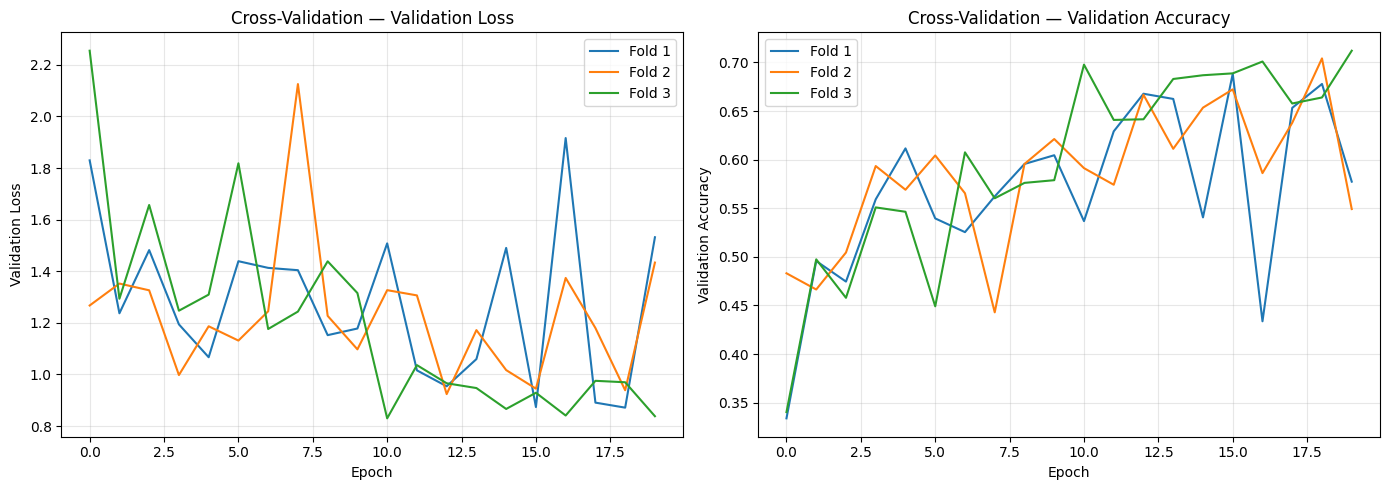

In [24]:
# Cross-Validation Ergebnisse zusammenfassen
best_accs = [r["best_val_acc"] for r in fold_results]
final_accs = [r["final_val_acc"] for r in fold_results]

print("Cross-Validation Ergebnisse:")
print(f"{'Fold':>6} | {'Best Val Acc':>12} | {'Final Val Acc':>13}")
print("-" * 40)
for r in fold_results:
    print(f"{r['fold']:>6} | {r['best_val_acc']:>12.4f} | {r['final_val_acc']:>13.4f}")
print("-" * 40)
print(f"{'Mean':>6} | {np.mean(best_accs):>12.4f} | {np.mean(final_accs):>13.4f}")
print(f"{'Std':>6} | {np.std(best_accs):>12.4f} | {np.std(final_accs):>13.4f}")

print(
    f"\nStatistischer Fehler (Best Val Acc): {np.mean(best_accs):.4f} +/- {np.std(best_accs):.4f}"
)
print(f"Hyperparameter: lr={best_lr}, batch_size={best_bs}")

# Lernkurven aller Folds plotten
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for r in fold_results:
    epochs = range(len(r["history"]["val_loss"]))
    ax1.plot(epochs, r["history"]["val_loss"], label=f"Fold {r['fold']}")
    ax2.plot(epochs, r["history"]["val_acc"], label=f"Fold {r['fold']}")

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Validation Loss")
ax1.set_title("Cross-Validation — Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel("Epoch")
ax2.set_ylabel("Validation Accuracy")
ax2.set_title("Cross-Validation — Validation Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()